In [ ]:
# =========================
# SECCION 1 - INSTALACIÓN DE DEPENDENCIAS
# =========================

# Se descomenta la primera vez que se corre en Google Colab para instalar todas las librerías requeridas para el sistema
!pip install numpy scipy matplotlib scikit-learn mesa==3.0 -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.3/223.3 kB 8.4 MB/s eta 0:00:00


In [ ]:
# =========================
# SECCION 2 - IMPORTS E INPUTS
# =========================

from mesa import Agent, Model
from mesa.space import SingleGrid # Espacio discreto donde se moveran los agentes
from mesa.space import MultiGrid
from mesa.time import RandomActivation # Para incluir Scheduler, qiue ayudará para ejecutar los agentes en orden aleatorio
from mesa.datacollection import DataCollector ## Para recolectar datos de la simulación

# Configuración de matplotlib para gráficas y animaciones
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"  # Para renderizar la animación directamente en Jupyter
matplotlib.rcParams['animation.embed_limit'] = 2**128 # Evita límite en animaciones grandes

# Librerías adicionales
import numpy as np
import pandas as pd
import time
import datetime

from collections import deque
import random

# Constantes para representar el estado de las celdas
EMPTY = 0 # Celda vacía
SMOKE = 1 # Celda con humo
FIRE = 2 # Celda con fuego
WALL = 3 # Celda con pared
DOOR_CLOSED = 4
DOOR_OPEN = 5
POI = 6 # Punto de interés (víctima/falsa alarma)


Could not import SolaraViz. If you need it, install with 'pip install --pre mesa[viz]'


In [ ]:
# =========================
# SECCIÓN 3 — AGENTE ASTRONAUTA
# =========================

from collections import deque
import random
from mesa import Agent

class Astronaut(Agent):
    """
    IA mejorada:
      - BFS para acercarse a objetivo.
      - Abre puertas cerradas (1 AP) antes de entrar.
      - Prioriza: POI vivo -> POI muerto -> POI none -> fuego -> humo.
      - Hace seguridad adyacente (apagar/limpiar) antes de avanzar.
      - Métricas para DataCollector.
    Requiere en el modelo: grid, wall_damage, door_state, poi_positions, victim_status,
      fire_positions, smoke_positions, nursing_pos, airlock_pos.
    """
    def __init__(self, unique_id, model):
        super().__init__(model)
        self.max_ap = 4
        self.ap = self.max_ap
        self.carrying = False
        self.carrying_status = None  # 'alive' | 'dead'
        self.victims_saved = 0
        self.fires_extinguished = 0
        self.smoke_cleared = 0
        self.pois_found = 0
        self.log = []  # Para registrar acciones por turno

    def _adjacent4(self, pos):
        x, y = pos
        return [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]

    def _cell_is_wall(self, pos):
        return pos in self.model.wall_damage and self.model.wall_damage[pos] < 2

    def _cell_is_door_closed(self, pos):
        return self.model.door_state.get(pos) == 'closed'

    def _neighbors_von_neumann(self, pos):
        x, y = pos
        candidates = [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]
        valid = []
        for nx, ny in candidates:
            if 0 <= nx < self.model.grid.width and 0 <= ny < self.model.grid.height:
                valid.append((nx, ny))
        return valid

    def _try_move(self, new_pos):
        if self.ap <= 0:
            return False
        if new_pos in self.model.fire_positions:
            return False
        if self._cell_is_wall(new_pos):
            return False
        if self._cell_is_door_closed(new_pos):
            if self.ap >= 2:
                self.open_door(new_pos)  # -1 AP
                self.model.grid.move_agent(self, new_pos)
                self.ap -= 1
                return True
            return False
        self.model.grid.move_agent(self, new_pos)
        self.ap -= 1
        return True

    def _bfs_next_step(self, start, goal):
        if start == goal:
            return None
        W, H = self.model.grid.width, self.model.grid.height
        q = deque([start])
        visited = {start}
        parent = {}
        def passable(p):
            x, y = p
            if not (0 <= x < W and 0 <= y < H):
                return False
            # puerta cerrada se permitirá en el plan (se abrirá al intentar entrar)
            if self._cell_is_wall(p):
                return False
            return True
        while q:
            cur = q.popleft()
            for nb in self._neighbors_von_neumann(cur):
                if nb in visited:
                    continue
                if not passable(nb):
                    continue
                visited.add(nb)
                parent[nb] = cur
                if nb == goal:
                    # reconstruir el primer paso desde start hacia goal
                    step = nb
                    while parent[step] != start:
                        step = parent[step]
                    return step
                q.append(nb)
        return None

    def _nearest(self, positions):
        if not positions:
            return None
        x0, y0 = self.pos
        return min(positions, key=lambda p: abs(p[0]-x0)+abs(p[1]-y0))

    def _select_target(self):
        alive_pois = [p for p in self.model.poi_positions if self.model.victim_status.get(p) == 'alive']
        dead_pois  = [p for p in self.model.poi_positions if self.model.victim_status.get(p) == 'dead']
        any_pois   = [p for p in self.model.poi_positions if self.model.victim_status.get(p) == 'none']
        for bucket in (alive_pois, dead_pois, any_pois, self.model.fire_positions, self.model.smoke_positions):
            if bucket:
                return self._nearest(bucket)
        return None

    def open_door(self, pos):
        if self.ap >= 1 and self._cell_is_door_closed(pos):
            self.model.door_state[pos] = 'open'
            self.ap -= 1

    def extinguish_fire(self, pos):
        if self.ap >= 2 and pos in self.model.fire_positions:
            self.model.fire_positions.remove(pos)
            self.fires_extinguished += 1
            self.ap -= 2

    def clear_smoke(self, pos):
        if self.ap >= 1 and pos in self.model.smoke_positions:
            self.model.smoke_positions.remove(pos)
            self.smoke_cleared += 1
            self.ap -= 1

    def _do_safety_adjacent(self):
        for nb in self._adjacent4(self.pos):
            if nb in self.model.fire_positions and self.ap >= 2:
                self.extinguish_fire(nb)
                return True
        for nb in self._adjacent4(self.pos):
            if nb in self.model.smoke_positions and self.ap >= 1:
                self.clear_smoke(nb)
                return True
        return False

    def _interact_here(self):
        if self.pos in self.model.poi_positions:
            status = self.model.victim_status.get(self.pos, 'none')
            self.pois_found += 1
            self.model.poi_positions.remove(self.pos)
            self.model.victim_status.pop(self.pos, None)
            if status in ('alive', 'dead') and not self.carrying:
                self.carrying = True
                self.carrying_status = status

    def _advance_towards(self, target_pos):
        if self.ap <= 0:
            return False
        step = self._bfs_next_step(self.pos, target_pos)
        if step is None:
            return False
        return self._try_move(step)

    def _random_move(self):
        neighbors = self._neighbors_von_neumann(self.pos)
        random.shuffle(neighbors)
        for pos in neighbors:
            if self._try_move(pos):
                return True
        return False

    def knockdown(self):
        """
        El astronauta es derribado por una explosión:
        - Pierde a la víctima (si la llevaba).
        - La víctima muere.
        - Es transportado a una celda del perímetro exterior.
        """
        if self.carrying and self.carrying_status in ("alive", "dead"):
            # Marcar la víctima como muerta
            self.model.victim_status[self.pos] = "dead"
            self.model.poi_positions.append(self.pos)
            self.carrying = False
            self.carrying_status = None

        # Mover al perímetro exterior
        perimeter = self.model._free_perimeter_spawns()
        if perimeter:
            new_pos = random.choice(perimeter)
            self.model.grid.move_agent(self, new_pos)

    def step(self):
        self.log = [f"Astronauta {self.unique_id} inicia turno en {self.pos} con {self.max_ap} AP."]
        self.ap = self.max_ap
        self._interact_here()

        while self.ap > 0:
            if self.carrying:
                target = self.model.nursing_pos if self.carrying_status == 'alive' else self.model.airlock_pos

                if self._do_safety_adjacent():
                    self.log.append(f"Realiza acción de seguridad adyacente en {self.pos}.")
                    continue

                if self.pos == target:
                    if self.carrying_status == 'alive':
                        self.victims_saved += 1
                        self.log.append(f"Entrega víctima viva en {target}.")
                    else:
                        self.log.append(f"Entrega víctima muerta en {target}.")
                    self.carrying = False
                    self.carrying_status = None
                    continue

                if self._advance_towards(target):
                    self.log.append(f"Se mueve hacia {target}.")
                    self._interact_here()
                    continue

                self._random_move()
                self.log.append(f"Se mueve aleatoriamente desde {self.pos}.")
                continue

            if self._do_safety_adjacent():
                self.log.append(f"Realiza acción de seguridad adyacente en {self.pos}.")
                continue

            prev_carry = self.carrying
            self._interact_here()
            if self.carrying and not prev_carry:
                self.log.append(f"Recoge víctima {self.carrying_status} en {self.pos}.")
                continue

            target = self._select_target()
            if target is None:
                self._random_move()
                self.log.append(f"No hay objetivo. Se mueve aleatoriamente desde {self.pos}.")
                continue

            if self._advance_towards(target):
                self.log.append(f"Se mueve hacia objetivo en {target}.")
                self._interact_here()
                continue

            self._random_move()
            self.log.append(f"No pudo avanzar. Se mueve aleatoriamente desde {self.pos}.")

In [ ]:
# =========================
# SECCIÓN 4 — Modelo
# =========================

from mesa import Model
from mesa.space import MultiGrid
from mesa.time import RandomActivation
from mesa.datacollection import DataCollector
import random
import numpy as np

class SpaceFightersModel(Model):
    def __init__(self, n_astronauts=4, n_fire=6, n_smoke=1, n_poi=3, max_ap=4, seed=None):
        super().__init__()
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        # Grid (15x15 compacto con perímetro exterior)
        self.grid = MultiGrid(17, 17, torus=False)

        # Scheduler
        self.schedule = RandomActivation(self)

        # Estado global
        self.max_ap = max_ap
        self.turn = 0
        self.damage_markers = 0
        self.game_over = False
        self.status = "En curso"
        self.current_step = 0
        self.finished_at = None

        # Estructuras y entidades
        self.wall_damage = {}     # {(x,y): 0/1/2} -> <2 bloquea; 2 = escombros (transitable)
        self.door_state = {}      # {(x,y): "closed"|"open"}
        self.poi_positions = []   # [(x,y), ...]
        self.victim_status = {}   # {(x,y): "alive"|"dead"|"none"}
        self.fire_positions = []  # [(x,y), ...]
        self.smoke_positions = [] # [(x,y), ...]

        # Mapa compacto (muros y puertas) + posiciones de Nursing/Airlock
        self.setup_compact_map()

        # Agentes
        self._place_astronauts(n_astronauts)

        # Objetos iniciales
        self._place_fire(n_fire)
        self._place_initial_smoke(n_smoke)
        self._place_pois(n_poi)

        # DataCollector (nombres con acentos para coincidir con tu Sección 9)
        self.datacollector = DataCollector(
            model_reporters={
                "rescued": lambda m: sum(a.victims_saved for a in m.schedule.agents),
                "lost": lambda m: len([s for s in m.victim_status.values() if s == "dead"]),
                "damage_markers": lambda m: m.damage_markers,
                "turn": lambda m: m.turn,
                "status": lambda m: m.status,
            },
            agent_reporters={
                "Víctimas Rescatadas": lambda a: a.victims_saved,
                "Fuegos Apagados":     lambda a: a.fires_extinguished,
                "Humo Apagado":        lambda a: a.smoke_cleared,
                "POIs Descubiertos":   lambda a: a.pois_found,
            }
        )

    # ---------- MAPA COMPACTO ----------
    def setup_compact_map(self):
        """
        Configura el mapa de juego basado en una matriz 17x17.
        0 = vacío, 1 = nursing, 2 = airlock, 3 = muro, 4 = puerta cerrada.
        """
        map_matrix = [
            [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            [0,3,3,3,3,3,4,3,3,4,3,3,3,3,3,3,0],
            [0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0],
            [0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0],
            [0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0],
            [0,3,0,0,0,0,0,4,0,0,4,0,0,0,0,4,0],
            [0,3,0,0,0,3,3,3,3,3,3,3,4,3,3,3,0],
            [0,3,0,0,0,4,0,0,0,0,0,3,0,0,0,3,0],
            [0,3,0,0,0,3,0,0,0,0,0,3,0,0,0,3,0],
            [0,3,0,0,0,3,0,0,0,0,0,4,0,0,0,3,0],
            [0,3,0,0,0,3,0,0,0,0,0,3,0,0,0,3,0],
            [0,3,3,3,4,3,3,3,3,3,3,3,4,3,3,3,0],
            [0,4,0,0,0,0,0,4,0,0,0,4,0,0,0,4,0],
            [0,3,0,0,0,0,0,3,0,0,0,3,0,0,0,3,0],
            [0,4,0,0,0,0,0,4,0,0,0,4,0,0,0,4,0],
            [0,3,3,3,3,3,4,3,3,3,3,3,3,4,3,3,0],
            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2]
        ]

        self.wall_damage.clear()
        self.door_state.clear()

        for y, row in enumerate(map_matrix):
            for x, cell in enumerate(row):
                pos = (x, y)
                if cell == 1:
                    self.nursing_pos = pos
                elif cell == 2:
                    self.airlock_pos = pos
                elif cell == 3:
                    self.wall_damage[pos] = 0
                elif cell == 4:
                    self.door_state[pos] = "closed"

    # ---------- SPAWNS ----------
    def _free_perimeter_spawns(self):
        """Centros de cada lado del perímetro exterior (fuera del edificio)."""
        W, H = self.grid.width, self.grid.height
        candidates = [(0, H//2), (W//2, 0), (W-1, H//2), (W//2, H-1)]
        return [(x, y) for (x, y) in candidates if 0 <= x < W and 0 <= y < H]

    def _place_astronauts(self, n):
        perim = self._free_perimeter_spawns()
        for i in range(n):
            pos = perim[i % len(perim)]
            a = Astronaut(i, self)
            self.grid.place_agent(a, pos)
            self.schedule.add(a)

    # ---------- HELPERS DE COLOCACIÓN ----------
    def _is_buildable_floor(self, pos):
        """Se puede colocar fuego/humo/POI aquí (no muro, no puerta, no exterior, no zonas especiales)."""
        x, y = pos
        W, H = self.grid.width, self.grid.height
        # Evitar perímetro exterior
        if x in (0, W-1) or y in (0, H-1):
            return False
        # Evitar muros y puertas
        if pos in self.wall_damage or pos in self.door_state:
            return False
        # Evitar Nursing/Airlock
        if pos in (self.nursing_pos, self.airlock_pos):
            return False
        return True

    def _place_fire(self, n):
        attempts = 0
        while n > 0 and attempts < 10000:
            x = random.randint(1, self.grid.width-2)
            y = random.randint(1, self.grid.height-2)
            pos = (x, y)
            if self._is_buildable_floor(pos) and pos not in self.fire_positions:
                self.fire_positions.append(pos)
                n -= 1
            attempts += 1

    def _place_initial_smoke(self, n):
        attempts = 0
        while n > 0 and attempts < 10000:
            x = random.randint(1, self.grid.width-2)
            y = random.randint(1, self.grid.height-2)
            pos = (x, y)
            if self._is_buildable_floor(pos) and pos not in self.fire_positions and pos not in self.smoke_positions:
                self.smoke_positions.append(pos)
                n -= 1
            attempts += 1

    def _place_pois(self, n):
        attempts = 0
        while n > 0 and attempts < 10000:
            x = random.randint(1, self.grid.width-2)
            y = random.randint(1, self.grid.height-2)
            pos = (x, y)
            if self._is_buildable_floor(pos) and pos not in self.poi_positions:
                self.poi_positions.append(pos)
                # 2 tipos de víctima y una falsa alarma
                self.victim_status[pos] = random.choice(["alive", "dead", "none"])
                n -= 1
            attempts += 1

    # ---------- DINÁMICA DEL ENTORNO ----------
    def _explode(self, pos):
        """Explosión al obtener fuego sobre fuego: daña estructuras adyacentes y puede derribar paredes."""
        neighbors = [(pos[0]+1, pos[1]), (pos[0]-1, pos[1]), (pos[0], pos[1]+1), (pos[0], pos[1]-1)]
        for npos in neighbors:
            x, y = npos
            if 0 <= x < self.grid.width and 0 <= y < self.grid.height:
                # Daño a paredes
                if npos in self.wall_damage:
                    self.wall_damage[npos] += 1
                    if self.wall_damage[npos] >= 2:
                        # pared queda como escombros (transitable); contamos marcador de daño global
                        self.damage_markers += 1
                # Daño a puertas
                elif npos in self.door_state:
                    # simplificación: puerta queda abierta y contamos daño global
                    self.door_state[npos] = "open"
                    self.damage_markers += 1
                # Astronautas en área -> knockdown
                for a in self.grid.get_cell_list_contents([npos]):
                    if isinstance(a, Astronaut):
                        a.knockdown()
                # POIs alcanzados -> muertos
                if npos in self.poi_positions:
                    self.victim_status[npos] = "dead"

    def _spread_fire(self):
        """Tiro de dados: interior aleatorio -> humo/fuego/explosión."""
        x = random.randint(1, self.grid.width - 2)
        y = random.randint(1, self.grid.height - 2)
        pos = (x, y)
        if pos in self.fire_positions:
            self._explode(pos)
        elif pos in self.smoke_positions:
            self.smoke_positions.remove(pos)
            self.fire_positions.append(pos)
        else:
            if self._is_buildable_floor(pos):
                self.smoke_positions.append(pos)

    # ---------- CICLO ----------
    def step(self):
        if self.game_over:
            return

        # Turno de agentes
        self.schedule.step()

        # Reponer POIs si hay menos de 3
        if len(self.poi_positions) < 3:
            self._place_pois(3 - len(self.poi_positions))

        # Evento del entorno al final del turno
        self._spread_fire()

        # Recolección y avance temporal
        self.turn += 1
        self.current_step = self.turn
        self.datacollector.collect(self)

        # Condiciones de término
        rescued_total = sum(a.victims_saved for a in self.schedule.agents)
        if self.damage_markers >= 24:
            self.game_over = True
            self.status = "Base colapsada"
            self.finished_at = self.turn
        elif rescued_total >= 6:
            self.game_over = True
            self.status = "Misión exitosa"
            self.finished_at = self.turn

    def run_until_done(self, max_steps=1000):
        for _ in range(max_steps):
            if self.game_over:
                break

            print(f"\n--- Turno {self.turn + 1} ---")  # Mostrar el turno antes de ejecutarlo
            self.step()

            for agent in self.schedule.agents:
                if hasattr(agent, "log"):
                    for line in agent.log:
                        print(line)

In [ ]:
"""
Mapa de la MATRIZ (Mapa)
0 = Celdas vacías (donde se puede exparcir el humo, el fuego o donde se pueden mover los astronautas aparte del perímetro exterior)
1 = Nursing
2 = Airlock
3 = Muros
4 = Puertas cerradas (que los astronautas van a tener que abrir)

{{1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0},
{0,3,3,3,3,3,4,3,3,4,3,3,3,3,3,3,0},
{0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0},
{0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0},
{0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0},
{0,3,0,0,0,0,0,4,0,0,4,0,0,0,0,4,0},
{0,3,0,0,0,3,3,3,3,3,3,3,4,3,3,3,0},
{0,3,0,0,0,4,0,0,0,0,0,3,0,0,0,3,0},
{0,3,0,0,0,3,0,0,0,0,0,3,0,0,0,3,0},
{0,3,0,0,0,3,0,0,0,0,0,4,0,0,0,3,0},
{0,3,0,0,0,3,0,0,0,0,0,3,0,0,0,3,0},
{0,3,3,3,4,3,3,3,3,3,3,3,4,3,3,3,0},
{0,4,0,0,0,0,0,4,0,0,0,4,0,0,0,4,0},
{0,3,0,0,0,0,0,3,0,0,0,3,0,0,0,3,0},
{0,4,0,0,0,0,0,4,0,0,0,4,0,0,0,4,0},
{0,3,3,3,3,3,4,3,3,3,3,3,3,4,3,3,0},
{0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2}}
"""

'\nMapa de la MATRIZ (Mapa)\n0 = Celdas vacías (donde se puede exparcir el humo, el fuego o donde se pueden mover los astronautas aparte del perímetro exterior)\n1 = Nursing\n2 = Airlock\n3 = Muros\n4 = Puertas cerradas (que los astronautas van a tener que abrir)\n\n{{1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0},\n{0,3,3,3,3,3,4,3,3,4,3,3,3,3,3,3,0},\n{0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0},\n{0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0},\n{0,3,0,0,0,0,0,3,0,0,3,0,0,0,0,3,0},\n{0,3,0,0,0,0,0,4,0,0,4,0,0,0,0,4,0},\n{0,3,0,0,0,3,3,3,3,3,3,3,4,3,3,3,0},\n{0,3,0,0,0,4,0,0,0,0,0,3,0,0,0,3,0},\n{0,3,0,0,0,3,0,0,0,0,0,3,0,0,0,3,0},\n{0,3,0,0,0,3,0,0,0,0,0,4,0,0,0,3,0},\n{0,3,0,0,0,3,0,0,0,0,0,3,0,0,0,3,0},\n{0,3,3,3,4,3,3,3,3,3,3,3,4,3,3,3,0},\n{0,4,0,0,0,0,0,4,0,0,0,4,0,0,0,4,0},\n{0,3,0,0,0,0,0,3,0,0,0,3,0,0,0,3,0},\n{0,4,0,0,0,0,0,4,0,0,0,4,0,0,0,4,0},\n{0,3,3,3,3,3,4,3,3,3,3,3,3,4,3,3,0},\n{0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2}}\n'

In [ ]:
# =========================
# SECCIÓN 5 — Parámetros, ejecución y reporte
# =========================
import time, datetime
import pandas as pd

# --- Parámetros de simulación ---
PARAMS = {
    "n_astronauts": 4,
    "n_fire": 6,        # empieza amable; luego puedes subir dificultad
    "n_smoke": 1,
    "n_poi": 3,
    "max_ap": 4,
    "seed": 42,
    "max_steps": 600,   # tope de seguridad de turnos
}

print("== Parámetros de la simulación ==")
for k, v in PARAMS.items():
    print(f"{k}: {v}")

# --- Instanciar y correr ---
start_time = time.time()
model = SpaceFightersModel(
    n_astronauts=PARAMS["n_astronauts"],
    n_fire=PARAMS["n_fire"],
    n_smoke=PARAMS["n_smoke"],
    n_poi=PARAMS["n_poi"],
    max_ap=PARAMS["max_ap"],
    seed=PARAMS["seed"]
)

model.run_until_done(max_steps=PARAMS["max_steps"])

elapsed = str(datetime.timedelta(seconds=(time.time() - start_time)))
print("\n== Ejecución terminada ==")
print("Tiempo de ejecución:", elapsed)
steps_to_finish = model.finished_at if model.finished_at is not None else model.turn
print(f"Pasos requeridos para finalizar la simulación: {steps_to_finish}")
print(f"Estado final: {model.status}")

# --- Recolección de datos desde DataCollector ---
model_df  = model.datacollector.get_model_vars_dataframe()
agents_df = model.datacollector.get_agent_vars_dataframe()

# Métricas globales finales (con defensas por si faltan columnas)
if not model_df.empty:
    rescued = model_df["rescued"].iloc[-1] if "rescued" in model_df.columns else 0
    lost    = model_df["lost"].iloc[-1] if "lost" in model_df.columns else 0
    damage  = model_df["damage_markers"].iloc[-1] if "damage_markers" in model_df.columns else 0
else:
    rescued = lost = damage = 0

print("\n== Métricas globales (último estado) ==")
print(f"Víctimas salvadas: {rescued}")
print(f"Víctimas perdidas: {lost}")
print(f"Daño a la base: {damage}")

# --- Mostrar últimas filas de los DataFrames ---
print("\n== Últimos registros del modelo ==")
try:
    from IPython.display import display
    display(model_df.tail())
except Exception:
    print(model_df.tail())

print("\n== Últimos registros de los agentes ==")
try:
    from IPython.display import display
    display(agents_df.tail())
except Exception:
    print(agents_df.tail())

# --- Resumen por agente (último paso por AgentID) ---
print("\n== Resumen por Agente ==")
if agents_df is None or agents_df.empty:
    print("No hay datos de agentes (¿se ejecutaron 0 pasos?).")
else:
    tmp = (
        agents_df
        .reset_index()            # columnas: Step, AgentID, métricas...
        .sort_values("Step")
    )
    final_agent_data = tmp.groupby("AgentID", as_index=False).tail(1).set_index("AgentID")

    # Columnas esperadas (coinciden con agent_reporters de la Sección 4)
    columns_to_show = [
        "Víctimas Rescatadas",
        "Fuegos Apagados",
        "Humo Apagado",
        "POIs Descubiertos",
    ]
    # Filtra sólo las que existen realmente
    columns_to_show = [c for c in columns_to_show if c in final_agent_data.columns]

    if columns_to_show:
        try:
            from IPython.display import display
            display(final_agent_data[columns_to_show])
        except Exception:
            print(final_agent_data[columns_to_show])
        # Totales
        print("\n-- Verificación de Totales --")
        for col in columns_to_show:
            total = final_agent_data[col].sum()
            print(f"Total de {col.lower()} (suma de agentes): {total}")
    else:
        print("No hay métricas por agente disponibles. Revisa los nombres en agent_reporters.")

# --- (Opcional) Guardar CSVs ---
SAVE_CSV = False  # cambia a True si quieres guardar
if SAVE_CSV:
    model_df.to_csv("model_log.csv", index=True)
    agents_df.to_csv("agents_log.csv", index=True)
    print("\nSe guardaron 'model_log.csv' y 'agents_log.csv' en el directorio de trabajo.")

== Parámetros de la simulación ==
n_astronauts: 4
n_fire: 6
n_smoke: 1
n_poi: 3
max_ap: 4
seed: 42
max_steps: 600

--- Turno 1 ---
Astronauta 4 inicia turno en (8, 16) con 4 AP.
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Astronauta 2 inicia turno en (8, 0) con 4 AP.
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Astronauta 3 inicia turno en (16, 8) con 4 AP.
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Astronauta 1 inicia turno en (0, 8) con 4 AP.
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).

--- Turno 2 ---
Astronauta 4 inicia turno en (12, 16) con 4 AP.
Se mueve hacia objetivo en (12, 9).
Se mueve hacia objetivo en (12, 9).
Se mue

/tmp/ipython-input-3235424537.py:23: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in a future version. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = RandomActivation(self)


,rescued,lost,damage_markers,turn,status
37,4,2,0,38,En curso
38,5,2,0,39,En curso
39,5,2,0,40,En curso
40,5,1,0,41,En curso
41,6,1,0,42,En curso



== Últimos registros de los agentes ==


Víctimas Rescatadas  Fuegos Apagados  Humo Apagado  \
Step AgentID                                                       
41   1                          0                3             3   
42   4                          2                0             3   
     3                          3                0             2   
     2                          1                1             5   
     1                          0                3             3   

              POIs Descubiertos  
Step AgentID                     
41   1                        6  
42   4                        8  
     3                        7  
     2                        5  
     1                        6


== Resumen por Agente ==


,Víctimas Rescatadas,Fuegos Apagados,Humo Apagado,POIs Descubiertos
AgentID,,,,
4,2,0,3,8
3,3,0,2,7
2,1,1,5,5
1,0,3,3,6



-- Verificación de Totales --
Total de víctimas rescatadas (suma de agentes): 6
Total de fuegos apagados (suma de agentes): 4
Total de humo apagado (suma de agentes): 13
Total de pois descubiertos (suma de agentes): 26


== Últimos registros del modelo ==


,rescued,lost,damage_markers,turn,status
37,4,2,0,38,En curso
38,5,2,0,39,En curso
39,5,2,0,40,En curso
40,5,1,0,41,En curso
41,6,1,0,42,En curso



== Últimos registros de los agentes ==


Víctimas Rescatadas  Fuegos Apagados  Humo Apagado  \
Step AgentID                                                       
41   1                          0                3             3   
42   4                          2                0             3   
     3                          3                0             2   
     2                          1                1             5   
     1                          0                3             3   

              POIs Descubiertos  
Step AgentID                     
41   1                        6  
42   4                        8  
     3                        7  
     2                        5  
     1                        6


== Series del modelo (resumen por turno) ==


,rescued,lost,damage_markers,turn
37,4,2,0,38
38,5,2,0,39
39,5,2,0,40
40,5,1,0,41
41,6,1,0,42


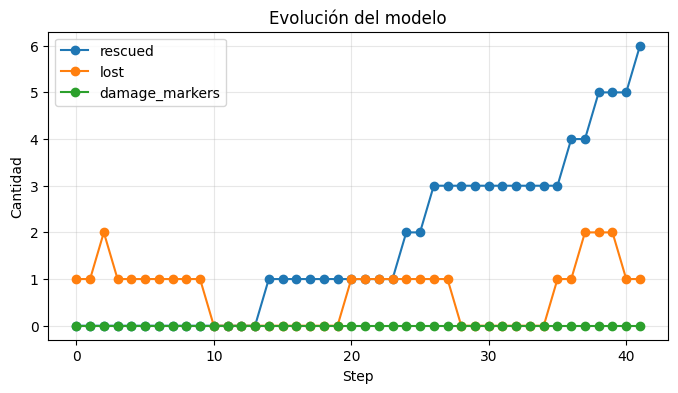


== Resumen por Agente (último step) ==


,Víctimas Rescatadas,Fuegos Apagados,Humo Apagado,POIs Descubiertos
AgentID,,,,
4,2,0,3,8
3,3,0,2,7
2,1,1,5,5
1,0,3,3,6



-- Totales por métrica (suma de agentes) --
Víctimas Rescatadas: 6
Fuegos Apagados: 4
Humo Apagado: 13
POIs Descubiertos: 26

== Evolución por agente (series de tiempo) ==


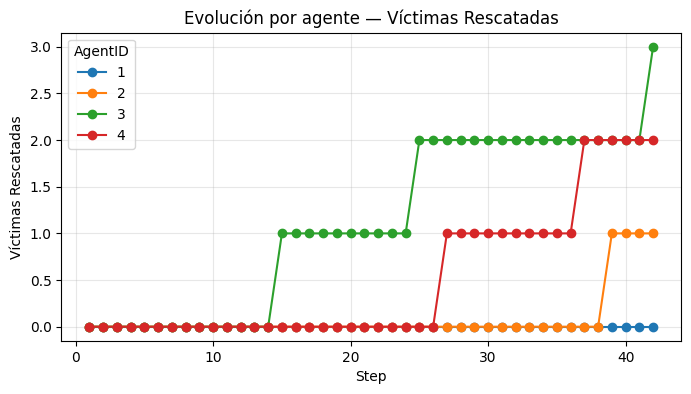

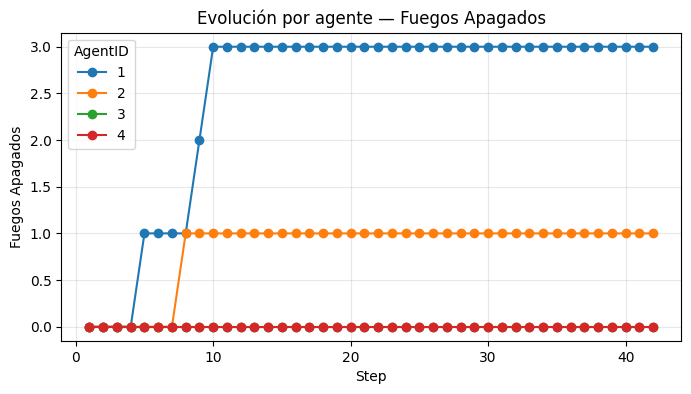

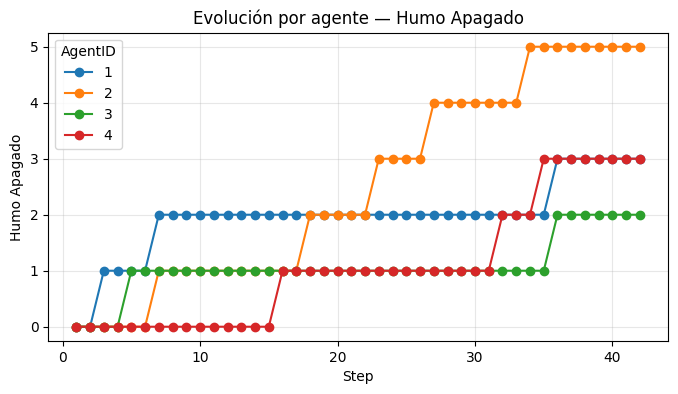

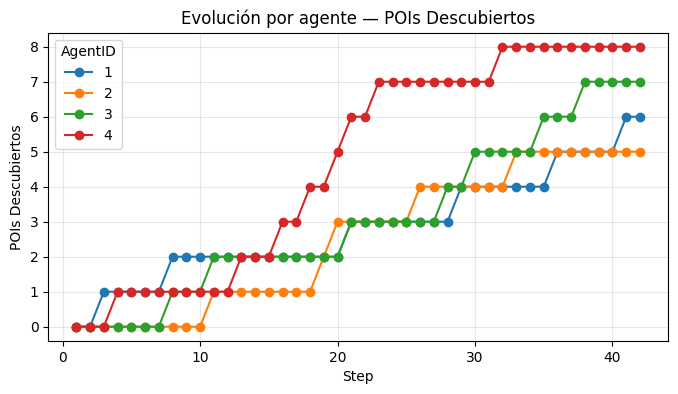

In [ ]:
# =========================
# SECCIÓN 6 — Datos del DataCollector y visualizaciones rápidas
# =========================
import pandas as pd
import matplotlib.pyplot as plt

# Recuperar datos (por si se ejecuta esta celda de forma independiente)
model_df  = model.datacollector.get_model_vars_dataframe()
agents_df = model.datacollector.get_agent_vars_dataframe()

print("== Últimos registros del modelo ==")
try:
    from IPython.display import display
    display(model_df.tail())
except Exception:
    print(model_df.tail())

print("\n== Últimos registros de los agentes ==")
try:
    from IPython.display import display
    display(agents_df.tail())
except Exception:
    print(agents_df.tail())

# -----------------------------
# Limpieza y comprobaciones
# -----------------------------
if model_df is None or model_df.empty:
    print("\n[AVISO] model_df está vacío. ¿Se ejecutaron 0 pasos? Revisa run_until_done/max_steps.")
if agents_df is None or agents_df.empty:
    print("[AVISO] agents_df está vacío. ¿Se ejecutaron 0 pasos? Revisa run_until_done/max_steps.")

# -----------------------------
# 6.1 Series de tiempo del modelo
# -----------------------------
print("\n== Series del modelo (resumen por turno) ==")
cols_model = [c for c in ["rescued", "lost", "damage_markers", "turn"] if c in model_df.columns]
if cols_model:
    try:
        display(model_df[cols_model].tail())
    except:
        print(model_df[cols_model].tail())

    # Graficar si hay al menos una columna numérica
    numeric_cols = [c for c in ["rescued", "lost", "damage_markers"] if c in model_df.columns]
    if numeric_cols:
        ax = model_df[numeric_cols].plot(figsize=(8, 4), marker="o")
        ax.set_title("Evolución del modelo")
        ax.set_xlabel("Step")
        ax.set_ylabel("Cantidad")
        ax.grid(True, alpha=0.3)
        plt.show()
else:
    print("No hay columnas del modelo disponibles para mostrar (rescued/lost/damage_markers/turn).")

# -----------------------------
# 6.2 Resumen por agente (último registro por AgentID)
# -----------------------------
print("\n== Resumen por Agente (último step) ==")
if agents_df is not None and not agents_df.empty:
    tmp = (
        agents_df
        .reset_index()            # columnas: Step, AgentID, métricas...
        .sort_values("Step")
    )
    final_agent_data = tmp.groupby("AgentID", as_index=False).tail(1).set_index("AgentID")

    # Columnas esperadas (deben coincidir con agent_reporters de la Sección 4)
    cols_agent = [
        "Víctimas Rescatadas",
        "Fuegos Apagados",
        "Humo Apagado",
        "POIs Descubiertos",
    ]
    cols_agent = [c for c in cols_agent if c in final_agent_data.columns]

    if cols_agent:
        try:
            display(final_agent_data[cols_agent])
        except Exception:
            print(final_agent_data[cols_agent])

        # Totales
        print("\n-- Totales por métrica (suma de agentes) --")
        for col in cols_agent:
            total = pd.to_numeric(final_agent_data[col], errors="coerce").fillna(0).sum()
            print(f"{col}: {int(total)}")
    else:
        print("No se encontraron columnas de métricas por agente. Verifica agent_reporters.")
else:
    print("No hay datos de agentes disponibles.")

# -----------------------------
# 6.3 Evolución por agente (series por métrica)
# -----------------------------
print("\n== Evolución por agente (series de tiempo) ==")
if agents_df is not None and not agents_df.empty:
    metrics = [
        "Víctimas Rescatadas",
        "Fuegos Apagados",
        "Humo Apagado",
        "POIs Descubiertos",
    ]
    base = agents_df.reset_index()  # Step, AgentID, ...
    for metric in metrics:
        if metric not in base.columns:
            continue
        wide = (
            base
            .pivot(index="Step", columns="AgentID", values=metric)
            .sort_index()
            .fillna(0)
        )
        # Si todo es cero, igual mostramos la figura para confirmar ausencia de acción
        ax = wide.plot(figsize=(8, 4), marker="o")
        ax.set_title(f"Evolución por agente — {metric}")
        ax.set_xlabel("Step")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
        plt.show()
else:
    print("No hay datos de agentes para graficar.")

# -----------------------------
# 6.4 Exportar (opcional)
# -----------------------------
EXPORTAR_CSV = False  # cambia a True si quieres guardar los CSV
if EXPORTAR_CSV:
    model_df.to_csv("model_log.csv", index=True)
    agents_df.to_csv("agents_log.csv", index=True)
    print("\n[OK] Se guardaron 'model_log.csv' y 'agents_log.csv'.")

In [ ]:
# =========================
# SECCIÓN 7 — Modelo de la animación
# =========================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm

EMPTY, SMOKE, FIRE, WALL, DOOR_CLOSED, DOOR_OPEN, POI, ASTRONAUT, NURSING_CODE, AIRLOCK_CODE = 0,1,2,3,4,5,6,7,8,9

# Colores pedidos
colors = [
    '#FFFFFF',  # 0 vacío -> blanco
    '#9E9E9E',  # 1 humo -> gris
    '#D32F2F',  # 2 fuego -> rojo
    '#8B5A2B',  # 3 pared -> café
    '#1B5E20',  # 4 puerta cerrada -> verde oscuro
    '#66BB6A',  # 5 puerta abierta -> verde claro
    '#7E57C2',  # 6 POI -> lila (puedes cambiarlo)
    '#FDD835',  # 7 astronauta -> amarillo
    '#1976D2',  # 8 nursing -> azul
    '#000000',  # 9 airlock -> negro
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

def get_grid_for_animation(model):
    g = np.zeros((model.grid.height, model.grid.width), dtype=int)
    for (x,y), dmg in model.wall_damage.items():
        if dmg < 2: g[y, x] = WALL
    for (x,y), st in model.door_state.items():
        g[y, x] = DOOR_CLOSED if st == "closed" else DOOR_OPEN
    for (x,y) in model.smoke_positions: g[y, x] = SMOKE
    for (x,y) in model.fire_positions:  g[y, x] = FIRE
    for (x,y) in model.poi_positions:   g[y, x] = POI
    for a in model.schedule.agents:
        if hasattr(a, "pos") and a.pos is not None:
            x, y = a.pos; g[y, x] = ASTRONAUT
    nx, ny = model.nursing_pos; g[ny, nx] = NURSING_CODE
    ax, ay = model.airlock_pos; g[ay, ax] = AIRLOCK_CODE
    return g

def animate_model(model, max_steps=400):
    frames = []
    for _ in range(max_steps):
        if model.game_over: break
        model.step()
        frames.append(get_grid_for_animation(model))
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_xticks([]); ax.set_yticks([])
    im = ax.imshow(frames[0], cmap=cmap, norm=norm, interpolation="nearest")
    def _upd(i):
        im.set_data(frames[i]); ax.set_title(f"Turno: {i}"); return (im,)
    return animation.FuncAnimation(fig, _upd, frames=len(frames), interval=200, blit=True)

/tmp/ipython-input-3235424537.py:23: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in a future version. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = RandomActivation(self)


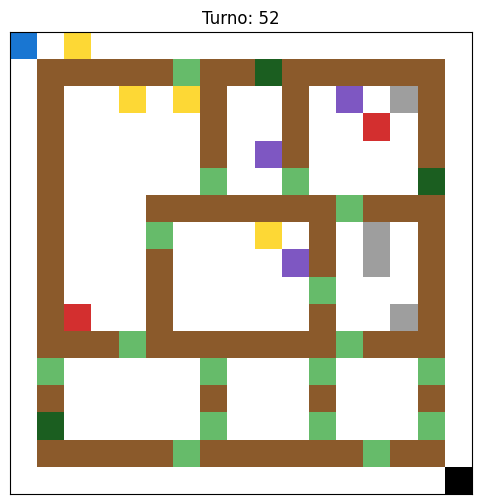

In [ ]:
# =========================
# SECCIÓN 8 — Animación
# =========================

model = SpaceFightersModel(n_astronauts=4, n_fire=16, n_smoke=1, n_poi=3, max_ap=4, seed=42)
# Si quieres animar en notebook:
anim = animate_model(model, max_steps=400)
anim  # en Colab/Jupyter se renderiza

In [ ]:
# =========================
# SECCIÓN 9 — Resultados de la simulación
# =========================

print("== Resultados finales ==")
print(f"Pasos necesarios para finalizar la simulación: {model.turn}")
print(f"Estado final: {model.status}")

# Obtener datos del modelo y de los agentes (asegúrate de volver a obtener ambos)
model_df  = model.datacollector.get_model_vars_dataframe()
agents_df = model.datacollector.get_agent_vars_dataframe()

# Valores finales del modelo (con defensas por si faltan columnas)
if not model_df.empty:
    rescued = model_df["rescued"].iloc[-1] if "rescued" in model_df.columns else 0
    lost    = model_df["lost"].iloc[-1] if "lost" in model_df.columns else 0
    damage  = model_df["damage_markers"].iloc[-1] if "damage_markers" in model_df.columns else 0
else:
    rescued = lost = damage = 0

print(f"Víctimas salvadas: {rescued}")
print(f"Víctimas perdidas: {lost}")
print(f"Daño a la base: {damage}")

# -----------------------------
# Resumen por agente (sin NaN)
# -----------------------------
print("\n--- Resumen por Agente ---")
if agents_df is None or agents_df.empty:
    print("No hay datos disponibles de los agentes (¿se ejecutaron 0 pasos?).")
else:
    # agents_df viene con MultiIndex (Step, AgentID). Tras reset_index() habrá columnas 'Step' y 'AgentID'
    tmp = (agents_df
           .reset_index()           # columnas: Step, AgentID, métricas...
           .sort_values('Step'))

    # Tomar el último registro de cada agente (el del paso más reciente)
    final_agent_data = tmp.groupby('AgentID', as_index=False).tail(1)

    # Renombrar columnas, si fuera necesario (solo si existen)
    column_map = {
        'Victimas Rescatadas': 'Víctimas Rescatadas',  # por si alguna vez guardaste sin acento
        'Fuegos Apagados': 'Fuegos Apagados',
        'Humo Apagado': 'Humo Apagado',
        'POIs Descubiertos': 'POIs Descubiertos'
    }
    final_agent_data = final_agent_data.rename(
        columns={k: v for k, v in column_map.items() if k in final_agent_data.columns}
    )

    # Qué columnas mostrar (toma en cuenta el nombre EXACTO que pusiste en el DataCollector)
    possible_cols = ["Víctimas Rescatadas", "Fuegos Apagados", "Humo Apagado", "POIs Descubiertos"]
    columns_to_show = [c for c in possible_cols if c in final_agent_data.columns]

    if columns_to_show:
        # Mostrar como tabla (si estás en Colab, puedes usar display)
        try:
            from IPython.display import display
            display(final_agent_data.set_index('AgentID')[columns_to_show])
        except Exception:
            print(final_agent_data.set_index('AgentID')[columns_to_show])

        # Totales globales
        print("\n--- Verificación de Totales ---")
        for col in columns_to_show:
            total = final_agent_data[col].sum()
            print(f"Total de {col.lower()} (suma de agentes): {total}")
    else:
        print("No hay métricas por agente disponibles (verifica los nombres en agent_reporters del DataCollector).")

== Resultados finales ==
Pasos necesarios para finalizar la simulación: 53
Estado final: Misión exitosa
Víctimas salvadas: 6
Víctimas perdidas: 1
Daño a la base: 0

--- Resumen por Agente ---


,Víctimas Rescatadas,Fuegos Apagados,Humo Apagado,POIs Descubiertos
AgentID,,,,
4,1,2,4,7
3,0,3,8,7
2,3,6,3,9
1,2,3,6,7



--- Verificación de Totales ---
Total de víctimas rescatadas (suma de agentes): 6
Total de fuegos apagados (suma de agentes): 14
Total de humo apagado (suma de agentes): 21
Total de pois descubiertos (suma de agentes): 30
